In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from datetime import timedelta
from sklearn.model_selection import TimeSeriesSplit
from holidays import country_holidays
from collections import defaultdict


In [2]:

receivals = pd.read_csv('./Project_materials/data/kernel/receivals.csv')
purchase_orders = pd.read_csv('./Project_materials/data/kernel/purchase_orders.csv')
prediction_mapping = pd.read_csv('./Project_materials/data/prediction_mapping.csv')
sample_submission = pd.read_csv('./Project_materials/data/sample_submission.csv')

# Convert dates
receivals['date_arrival'] = pd.to_datetime(receivals['date_arrival'], utc=True).dt.tz_localize(None)
purchase_orders['delivery_date'] = pd.to_datetime(purchase_orders['delivery_date'], utc=True).dt.tz_localize(None)
purchase_orders['created_date_time'] = pd.to_datetime(purchase_orders['created_date_time'], utc=True).dt.tz_localize(None)
prediction_mapping['forecast_start_date'] = pd.to_datetime(prediction_mapping['forecast_start_date'])
prediction_mapping['forecast_end_date'] = pd.to_datetime(prediction_mapping['forecast_end_date'])


receivals = receivals[receivals['net_weight'] > 0]
receivals = receivals[receivals['rm_id'].notna()]
receivals = receivals.sort_values('date_arrival').reset_index(drop=True)


rmid_dict = receivals.groupby('purchase_order_id')['rm_id'].first().to_dict()
purchase_orders['rm_id'] = purchase_orders['purchase_order_id'].map(rmid_dict)

purchase_orders = purchase_orders[purchase_orders['rm_id'].notna()]
purchase_orders = purchase_orders[purchase_orders['unit'] == 'KG']
purchase_orders = purchase_orders.sort_values('delivery_date').reset_index(drop=True)


receivals['date_arrival'] = pd.to_datetime(receivals['date_arrival'].dt.date)
purchase_orders['delivery_date'] = pd.to_datetime(purchase_orders['delivery_date'].dt.date)
purchase_orders['created_date_time'] = pd.to_datetime(purchase_orders['created_date_time'].dt.date)


first_recv = receivals.groupby('rm_id')['date_arrival'].min().rename('first_receival')
activation = first_recv.rename('activation_date')




In [3]:
prediction_mapping.head(-1)

,ID,rm_id,forecast_start_date,forecast_end_date
0,1,365,2025-01-01,2025-01-02
1,2,365,2025-01-01,2025-01-03
2,3,365,2025-01-01,2025-01-04
3,4,365,2025-01-01,2025-01-05
4,5,365,2025-01-01,2025-01-06
...,...,...,...,...
30444,30445,4501,2025-01-01,2025-05-26
30445,30446,4501,2025-01-01,2025-05-27
30446,30447,4501,2025-01-01,2025-05-28
30447,30448,4501,2025-01-01,2025-05-29


In [4]:
print(activation.get(3865.0))

2023-06-05 00:00:00


In [5]:
train_date_start = '2024-01-01'
train_dates = pd.date_range(start=train_date_start, end='2024-11-30', freq='D')
forecast_horizons = [7, 30, 60, 90, 150]


In [6]:
training_data = []
active_rm_ids_rec = receivals[(receivals['date_arrival'] >= '2024-01-01')]['rm_id'].unique()
active_rm_ids_po = purchase_orders[(purchase_orders['delivery_date'] >= '2024-01-01')]['rm_id'].unique()
active_rm_ids = set(active_rm_ids_rec).union(set(active_rm_ids_po))

# ============================================================================
# PRE-COMPUTE RM_ID CHARACTERISTICS FOR SPLITTING
# ============================================================================
print("\n[PRE-ANALYSIS] Computing rm_id activity levels...")

rm_characteristics = {}
for rm_id in active_rm_ids:
    hist_full = receivals[
    (receivals['rm_id'] == rm_id) &
    (receivals['date_arrival'] >= '2024-01-01')
    ]
    rm_characteristics[rm_id] = {
        'total_count': len(hist_full),
        'total_weight': hist_full['net_weight'].sum(),
        'avg_delivery_size': hist_full['net_weight'].mean()
    }

# Convert to DataFrame for easier analysis
rm_char_df = pd.DataFrame.from_dict(rm_characteristics, orient='index')
rm_char_df['rm_id'] = rm_char_df.index

print("\nRM_ID Activity Distribution:")
print(rm_char_df[['total_count', 'total_weight']].describe())


# ============================================================================
# DEFINE SPLIT CRITERIA 
# ============================================================================

count_thresh_high = rm_char_df['total_count'].quantile(0.95)
weight_thresh_high = rm_char_df['total_weight'].quantile(0.95)
mid_activity_rms = set(rm_char_df[
    (rm_char_df['total_count'] <= count_thresh_high) | 
    (rm_char_df['total_weight'] <= weight_thresh_high)
].index)
high_activity_rms = set(rm_char_df.index) - mid_activity_rms

count_thresh_mid = rm_char_df['total_count'].quantile(0.7)
weight_thresh_mid = rm_char_df['total_weight'].quantile(0.7)
low_activity_rms = set(rm_char_df[
    (rm_char_df['total_count'] <= count_thresh_mid) & 
    (rm_char_df['total_weight'] <= weight_thresh_mid)
].index)
mid_activity_rms = mid_activity_rms - low_activity_rms

print(f"\nSplit Results:")
print(f"  Low-activity materials: {len(low_activity_rms)}")
print(f"  Mid-activity materials: {len(mid_activity_rms)}")
print(f"  High-activity materials: {len(high_activity_rms)}")
print(f"  Mid threshold (count): {count_thresh_mid:.0f} deliveries")
print(f"  High threshold (count): {count_thresh_high:.0f} deliveries")




[PRE-ANALYSIS] Computing rm_id activity levels...

RM_ID Activity Distribution:
       total_count  total_weight
count    60.000000  6.000000e+01
mean     99.933333  1.435019e+06
std     200.191677  3.052478e+06
min       1.000000  2.000000e+03
25%       3.000000  4.789000e+04
50%      13.000000  2.019500e+05
75%     139.500000  6.316575e+05
max    1062.000000  1.503073e+07

Split Results:
  Low-activity materials: 38
  Mid-activity materials: 19
  High-activity materials: 3
  Mid threshold (count): 89 deliveries
  High threshold (count): 346 deliveries


In [7]:
# Print top 15 active rm_ids by weight and amount of receivals
# In descending order
sorted_by_weight = rm_char_df.copy().sort_values(by='total_count', ascending=False).head(20)
for rm_id in sorted_by_weight.index:
    print(f"RM_ID: {rm_id}, Total Weight: {sorted_by_weight.loc[rm_id, 'total_weight']}, Total Count: {sorted_by_weight.loc[rm_id, 'total_count']}")



RM_ID: 3865.0, Total Weight: 12215851.0, Total Count: 1062
RM_ID: 2130.0, Total Weight: 15030729.0, Total Count: 882
RM_ID: 3781.0, Total Weight: 10633107.0, Total Count: 636
RM_ID: 2142.0, Total Weight: 1216846.0, Total Count: 331
RM_ID: 3126.0, Total Weight: 6226620.0, Total Count: 330
RM_ID: 3125.0, Total Weight: 6317380.0, Total Count: 261
RM_ID: 2143.0, Total Weight: 350531.0, Total Count: 202
RM_ID: 3124.0, Total Weight: 4942040.0, Total Count: 197
RM_ID: 3282.0, Total Weight: 4877980.0, Total Count: 197
RM_ID: 2145.0, Total Weight: 485575.0, Total Count: 197
RM_ID: 3122.0, Total Weight: 4847160.0, Total Count: 196
RM_ID: 2134.0, Total Weight: 1598810.0, Total Count: 194
RM_ID: 3901.0, Total Weight: 2339910.0, Total Count: 164
RM_ID: 3123.0, Total Weight: 4043100.0, Total Count: 161
RM_ID: 3421.0, Total Weight: 393306.0, Total Count: 153
RM_ID: 2144.0, Total Weight: 556094.0, Total Count: 135
RM_ID: 2131.0, Total Weight: 624850.0, Total Count: 108
RM_ID: 2135.0, Total Weight: 902

## Feature Engineering

In [8]:
hdays = country_holidays('NO', years=[pd.year for pd in train_dates])
other_patterns = [f'-08-{13+i}' for i in range(12)]


In [9]:

for i, train_date in enumerate(train_dates):
    print(f"Processing date {i+1}/{len(train_dates)}: {train_date.date()}...")

    for rm_id in active_rm_ids:
        hist_receivals = receivals[
            (receivals['rm_id'] == rm_id) &
            (receivals['date_arrival'] < train_date)
        ]

        target = receivals[(receivals['rm_id'] == rm_id) &
                (receivals['date_arrival'] == train_date)
        ]
        if len(target) == 0:
            target = 0.0
        else:
            target = target['net_weight'].sum()
        
        
        # Determine activity level for this rm_id
        if rm_id in low_activity_rms:
            activity_level = 'low'
        elif rm_id in mid_activity_rms:
            activity_level = 'mid'
        else:
            activity_level = 'high'

        day_of_week = train_date.dayofweek
        day_of_month = train_date.day
        month = train_date.month
        is_weekend = 1 if day_of_week >= 5 else 0
        is_holiday = 1 if train_date in hdays else 0
        year = train_date.year
        is_other_pattern = 1 if any(pattern in train_date.strftime('%Y-%m-%d') for pattern in other_patterns) else 0

        cutoff_365 = train_date - timedelta(365)
        cutoff_180 = train_date - timedelta(180)
        cutoff_90 = train_date - timedelta(90)
        cutoff_30 = train_date - timedelta(30)
        cutoff_7 = train_date - timedelta(7)

        rec_365 = hist_receivals[hist_receivals['date_arrival'] >= cutoff_365]
        rec_180 = hist_receivals[hist_receivals['date_arrival'] >= cutoff_180]
        rec_90 = hist_receivals[hist_receivals['date_arrival'] >= cutoff_90]
        rec_30 = hist_receivals[hist_receivals['date_arrival'] >= cutoff_30]
        rec_7 = hist_receivals[hist_receivals['date_arrival'] >= cutoff_7]

        pos_on_day = purchase_orders[(purchase_orders['rm_id'] == rm_id) &
                    (purchase_orders['delivery_date'] == train_date)
        ]
        pos = pos_on_day['quantity'].sum() if len(pos_on_day) > 0 else 0.0

        av_pos_7d = purchase_orders[(purchase_orders['rm_id'] == rm_id) &
                    (purchase_orders['delivery_date'] >= train_date - timedelta(3)) &
                    (purchase_orders['delivery_date'] < train_date + timedelta(3))
        ]
        av_pos_7d = av_pos_7d['quantity'].mean() if len(av_pos_7d) > 0 else 0.0


        av_pos_15d = purchase_orders[(purchase_orders['rm_id'] == rm_id) &
                    (purchase_orders['delivery_date'] >= train_date - timedelta(7)) &
                    (purchase_orders['delivery_date'] < train_date + timedelta(7))
        ]
        av_pos_15d = av_pos_15d['quantity'].mean() if len(av_pos_15d) > 0 else 0.0

        activation_date = pd.to_datetime(activation.get(rm_id))
        activated = 1 if activation_date <= train_date else 0

        days_since_last_recv = (train_date - hist_receivals['date_arrival'].max()).days if len(hist_receivals) > 0 else np.nan


        training_data.append({
            'rm_id': rm_id,
            'train_date': train_date,
            'target': target,
            'activity_level': activity_level,
            'is_weekend': is_weekend,
            'is_holiday': is_holiday,
            'is_other_pattern': is_other_pattern,
            'day_of_week': day_of_week,
            'day_of_month': day_of_month,
            'month': month,
            'rec_count_7d': len(rec_7),
            'rec_weight_7d': rec_7['net_weight'].sum(),
            'rec_count_30d': len(rec_30),
            'rec_weight_30d': rec_30['net_weight'].sum(),
            'rec_count_90d': len(rec_90),
            'rec_weight_90d': rec_90['net_weight'].sum(),
            'rec_count_180d': len(rec_180),
            'rec_weight_180d': rec_180['net_weight'].sum(),
            'rec_count_365d': len(rec_365),
            'rec_weight_365d': rec_365['net_weight'].sum(),
            'days_since_last_recv': days_since_last_recv,
            'pos': pos,
            'av_pos_7d': av_pos_7d,
            'av_pos_15d': av_pos_15d,
            'activated': activated
        })


    # Convert to DataFrame
training_df = pd.DataFrame(training_data)
training_df = training_df.sort_values(['train_date']).reset_index(drop=True)

g = training_df.groupby('rm_id', group_keys=False)
y = g['target']

for k in [1, 2, 3, 7, 14, 28]:
    training_df[f'lag_{k}'] = y.shift(k)


# --- SHIFTED ROLLING STATS (use only history up to t-1) ---
training_df['target_shift1'] = y.shift(1)

def roll_apply(col, w, func, name):
    training_df[f'{name}_{w}d'] = g[col].apply(lambda s: s.rolling(w, min_periods=1).apply(func) 
                                               if func!=np.sum and func!=np.mean and func!='std' else None)

# sums/means
for w in [7, 14, 30, 90]:
    training_df[f'sum_{w}d']  = g['target_shift1'].apply(lambda s: s.rolling(w, min_periods=1).sum())
    training_df[f'mean_{w}d'] = g['target_shift1'].apply(lambda s: s.rolling(w, min_periods=1).mean())

# vol (optional but useful)
for w in [7, 30]:
    training_df[f'std_{w}d'] = g['target_shift1'].apply(lambda s: s.rolling(w, min_periods=2).std())

# --- ACTIVITY FREQUENCY (how often non-zero) ---
active_shift1 = (training_df['target_shift1'] > 0).astype(float)
training_df['active_ratio_30'] = g.apply(
    lambda sub: active_shift1.loc[sub.index].rolling(30, min_periods=1).mean()
).reset_index(level=0, drop=True)


Processing date 1/335: 2024-01-01...
Processing date 2/335: 2024-01-02...
Processing date 3/335: 2024-01-03...
Processing date 4/335: 2024-01-04...
Processing date 5/335: 2024-01-05...
Processing date 6/335: 2024-01-06...
Processing date 7/335: 2024-01-07...
Processing date 8/335: 2024-01-08...
Processing date 9/335: 2024-01-09...
Processing date 10/335: 2024-01-10...
Processing date 11/335: 2024-01-11...
Processing date 12/335: 2024-01-12...
Processing date 13/335: 2024-01-13...
Processing date 14/335: 2024-01-14...
Processing date 15/335: 2024-01-15...
Processing date 16/335: 2024-01-16...
Processing date 17/335: 2024-01-17...
Processing date 18/335: 2024-01-18...
Processing date 19/335: 2024-01-19...
Processing date 20/335: 2024-01-20...
Processing date 21/335: 2024-01-21...
Processing date 22/335: 2024-01-22...
Processing date 23/335: 2024-01-23...
Processing date 24/335: 2024-01-24...
Processing date 25/335: 2024-01-25...
Processing date 26/335: 2024-01-26...
Processing date 27/33

/var/folders/wb/b0kcxbx91yn4xk_l54_nhvy00000gn/T/ipykernel_92410/344559595.py:129: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  training_df['active_ratio_30'] = g.apply(


In [10]:

print(len(training_df), "training samples generated.")
training_df[(training_df['rm_id'] == 3865.0)].head(-1)


20100 training samples generated.


,rm_id,train_date,target,activity_level,is_weekend,is_holiday,is_other_pattern,day_of_week,day_of_month,month,...,mean_7d,sum_14d,mean_14d,sum_30d,mean_30d,sum_90d,mean_90d,std_7d,std_30d,active_ratio_30
33,3865.0,2024-01-01,0.0,high,0,1,0,0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
93,3865.0,2024-01-02,0.0,high,0,0,0,1,2,1,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,NaN,NaN,0.0
151,3865.0,2024-01-03,0.0,high,0,0,0,2,3,1,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0
212,3865.0,2024-01-04,0.0,high,0,0,0,3,4,1,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0
274,3865.0,2024-01-05,0.0,high,0,0,0,4,5,1,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19772,3865.0,2024-11-25,34380.0,high,0,0,0,0,25,11,...,31003.571429,452709.0,32336.357143,682293.0,22743.100000,2882856.0,32031.733333,24603.745107,23820.765727,0.0
19832,3865.0,2024-11-26,59641.0,high,0,0,0,1,26,11,...,29851.857143,423523.0,30251.642857,716673.0,23889.100000,2866915.0,31854.611111,24163.826756,23513.904088,0.0
19894,3865.0,2024-11-27,25320.0,high,0,0,0,2,27,11,...,29124.857143,433134.0,30938.142857,776314.0,25877.133333,2870947.0,31899.411111,22987.502477,23941.846094,0.0
19953,3865.0,2024-11-28,7300.0,high,0,0,0,3,28,11,...,29144.857143,417944.0,29853.142857,737154.0,24571.800000,2896267.0,32180.744444,22983.558837,22805.141637,0.0


## Activity Analysis

In [11]:
# ============================================================================
# ANALYZE THE SPLIT
# ============================================================================
train_df = training_df.copy()
print(f"\nGenerated {len(train_df)} training samples")

low_activity_samples = train_df[train_df['activity_level'] == 'low']
mid_activity_samples = train_df[train_df['activity_level'] == 'mid']
high_activity_samples = train_df[train_df['activity_level'] == 'high']

print("\nLow-activity materials:")
print(f"  Samples: {len(low_activity_samples)}")
print(f"  Avg target: {low_activity_samples['target'].mean():,.0f} kg")
print(f"  Target > 0: {(low_activity_samples['target'] > 0).sum()} ({(low_activity_samples['target'] > 0).mean()*100:.1f}%)")

print("\nMid-activity materials:")
print(f"  Samples: {len(mid_activity_samples)}")
print(f"  Avg target: {mid_activity_samples['target'].mean():,.0f} kg")
print(f"  Target > 0: {(mid_activity_samples['target'] > 0).sum()} ({(mid_activity_samples['target'] > 0).mean()*100:.1f}%)")

print("\nHigh-activity materials:")
print(f"  Samples: {len(high_activity_samples)}")
print(f"  Avg target: {high_activity_samples['target'].mean():,.0f} kg")
print(f"  Target > 0: {(high_activity_samples['target'] > 0).sum()} ({(high_activity_samples['target'] > 0).mean()*100:.1f}%)")



Generated 20100 training samples

Low-activity materials:
  Samples: 12730
  Avg target: 341 kg
  Target > 0: 271 (2.1%)

Mid-activity materials:
  Samples: 6365
  Avg target: 6,534 kg
  Target > 0: 2144 (33.7%)

High-activity materials:
  Samples: 1005
  Avg target: 35,586 kg
  Target > 0: 550 (54.7%)


## Training Models

In [19]:


# ============================================================================
# EXTRACT TRAINING HISTORIES FROM CROSS-VALIDATION
# ============================================================================
print("\n[PLOTTING] Extracting CV Training Histories")
print("-"*80)

# We need to re-run CV but save the history objects this time
# ============================================================================
# CV WITH HISTORY TRACKING - LOW-ACTIVITY MODEL
# ============================================================================

y_low = low_activity_samples['target']
y_mid = mid_activity_samples['target']
y_high = high_activity_samples['target']
X_low = low_activity_samples.copy().drop(axis=1, labels=['target', 'activity_level', 'target_shift1'])
X_mid = mid_activity_samples.copy().drop(axis=1, labels=['target', 'activity_level', 'target_shift1'])
X_high = high_activity_samples.copy().drop(axis=1, labels=['target', 'activity_level', 'target_shift1'])

# Drop datetime columns
for X in [X_low, X_mid, X_high]:
    datetime_cols = X.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns
    X.drop(columns=datetime_cols, inplace=True)


histories_low = []
tscv = TimeSeriesSplit(n_splits=9)

# ============================================================================
# CV WITH HISTORY TRACKING - MID-ACTIVITY MODEL
# ============================================================================

histories_mid = []
print("\nRunning MID-ACTIVITY CV with history tracking...")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_mid)):
    X_train_fold = X_mid.iloc[train_idx]
    y_train_fold = y_mid.iloc[train_idx]
    X_val_fold = X_mid.iloc[val_idx]
    y_val_fold = y_mid.iloc[val_idx]

    model_mid = lgb.LGBMRegressor(
        objective='quantile',
        alpha=0.20,
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.04,
        subsample=0.75,
        colsample_bytree=0.75,
        min_child_samples=20,
        reg_alpha=0.15,
        reg_lambda=0.15,
        random_state=42,
        verbose=-1
    )

    model_mid.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_train_fold, y_train_fold), (X_val_fold, y_val_fold)],
        eval_names=['train', 'valid'],
        categorical_feature=['month', 'day_of_week', 'rm_id', 'day_of_month', 'is_weekend', 'is_holiday', 'is_other_pattern', 'activated'],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    histories_mid.append({
        'fold': fold + 1,
        'train_loss': model_mid.evals_result_['train']['quantile'],
        'val_loss': model_mid.evals_result_['valid']['quantile'],
        'best_iteration': model_mid.best_iteration_
    })

    print(f"Fold {fold + 1}: Best iteration = {model_mid.best_iteration_}")

# ============================================================================
# CV WITH HISTORY TRACKING - HIGH-ACTIVITY MODEL
# ============================================================================

histories_high = []

print("\nRunning HIGH-ACTIVITY CV with history tracking...")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_high)):
    X_train_fold = X_high.iloc[train_idx]
    y_train_fold = y_high.iloc[train_idx]
    X_val_fold = X_high.iloc[val_idx]
    y_val_fold = y_high.iloc[val_idx]

    model_high = lgb.LGBMRegressor(
        objective='quantile',
        alpha=0.20,
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.7,
        colsample_bytree=0.7,
        min_child_samples=50,
        reg_alpha=0.2,
        reg_lambda=0.2,
        random_state=42,
        verbose=-1
    )

    model_high.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_train_fold, y_train_fold), (X_val_fold, y_val_fold)],
        eval_names=['train', 'valid'],
        categorical_feature=['month', 'day_of_week', 'rm_id', 'day_of_month', 'is_weekend', 'is_holiday', 'is_other_pattern', 'activated'],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    histories_high.append({
        'fold': fold + 1,
        'train_loss': model_high.evals_result_['train']['quantile'],
        'val_loss': model_high.evals_result_['valid']['quantile'],
        'best_iteration': model_high.best_iteration_
    })

    print(f"Fold {fold + 1}: Best iteration = {model_high.best_iteration_}")



[PLOTTING] Extracting CV Training Histories
--------------------------------------------------------------------------------

Running MID-ACTIVITY CV with history tracking...
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
Fold 1: Best iteration = 50
Fold 2: Best iteration = 108
Fold 3: Best iteration = 101
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
Fold 4: Best iteration = 65
Fold 5: Best iteration = 238
Fold 6: Best iteration = 1
Fold 7: Best iteration = 148
Fold 8: Best iteration = 74
Fold 9: Best iteration = 1

Running HIGH-ACTIVITY CV with history tracking...
Fold 1: Best iteration = 1
Fold 2: Best iteration = 39
Fold 3: Best iteration = 79
Fold 4: Best iteration = 24
Fold 5: Best iteration = 173
Fold 6: Best iteration = 1
Fold 7: Best iteration = 89
Fold 8: Best iteration = 42
Fold 9: Best iterati

## Plots

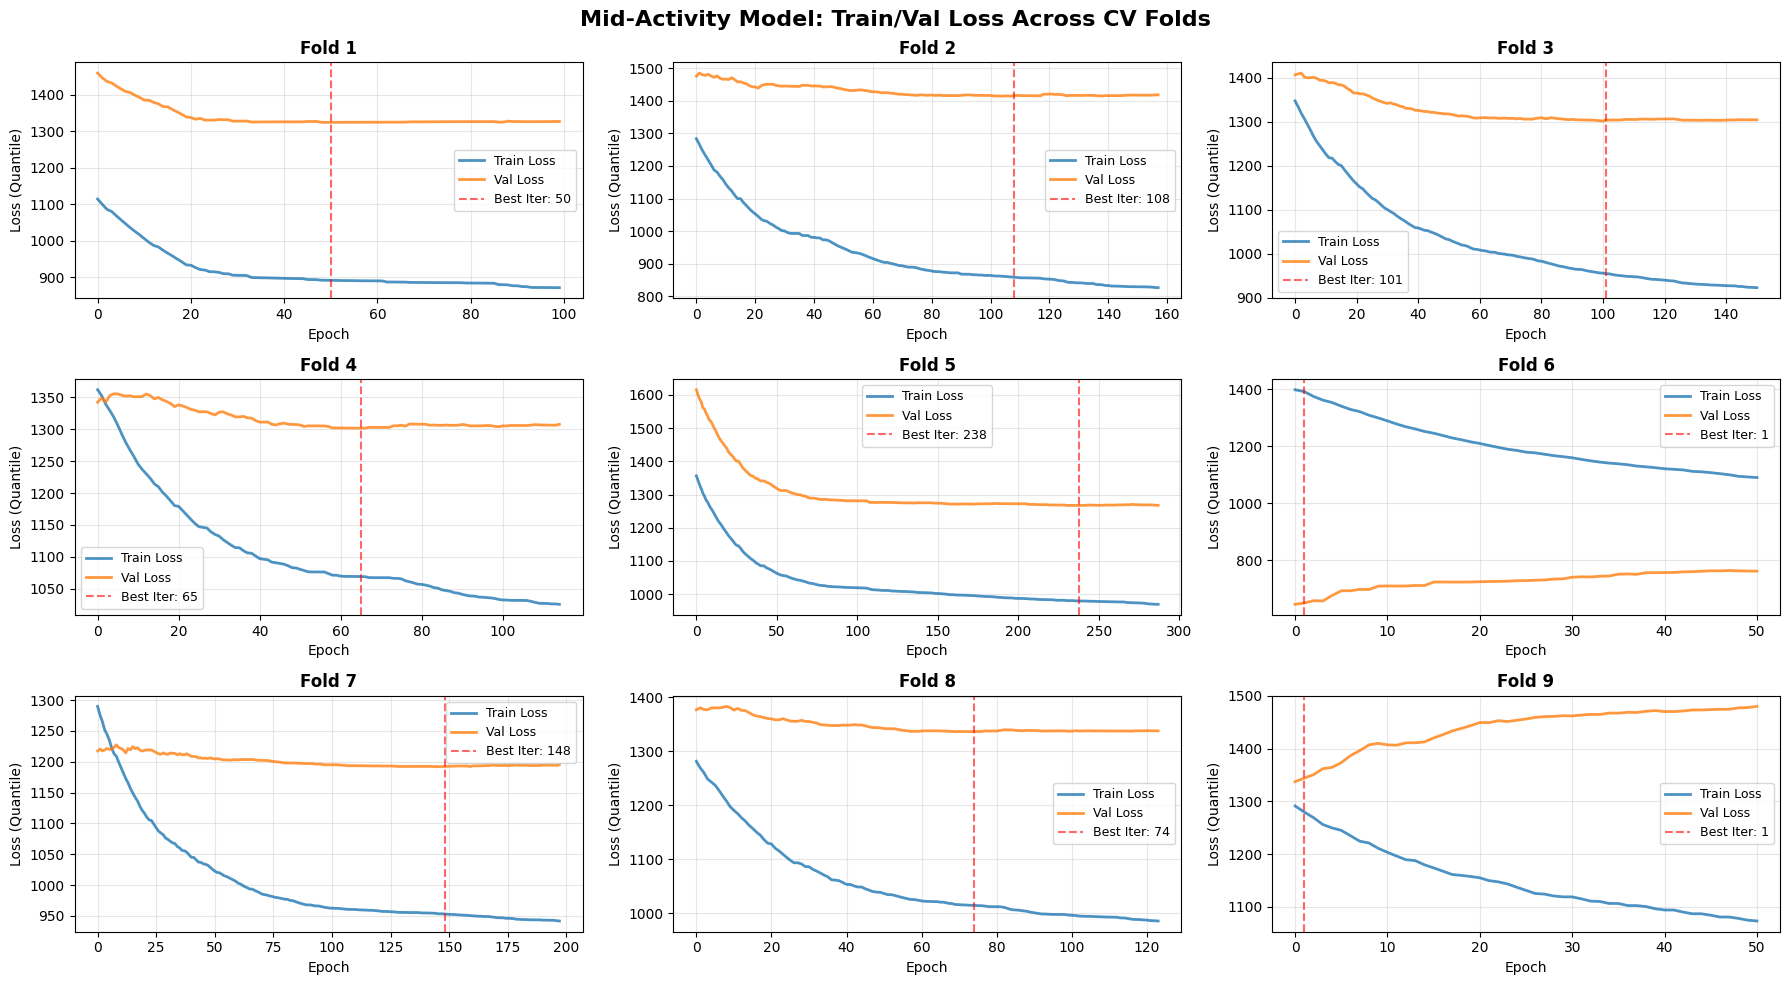

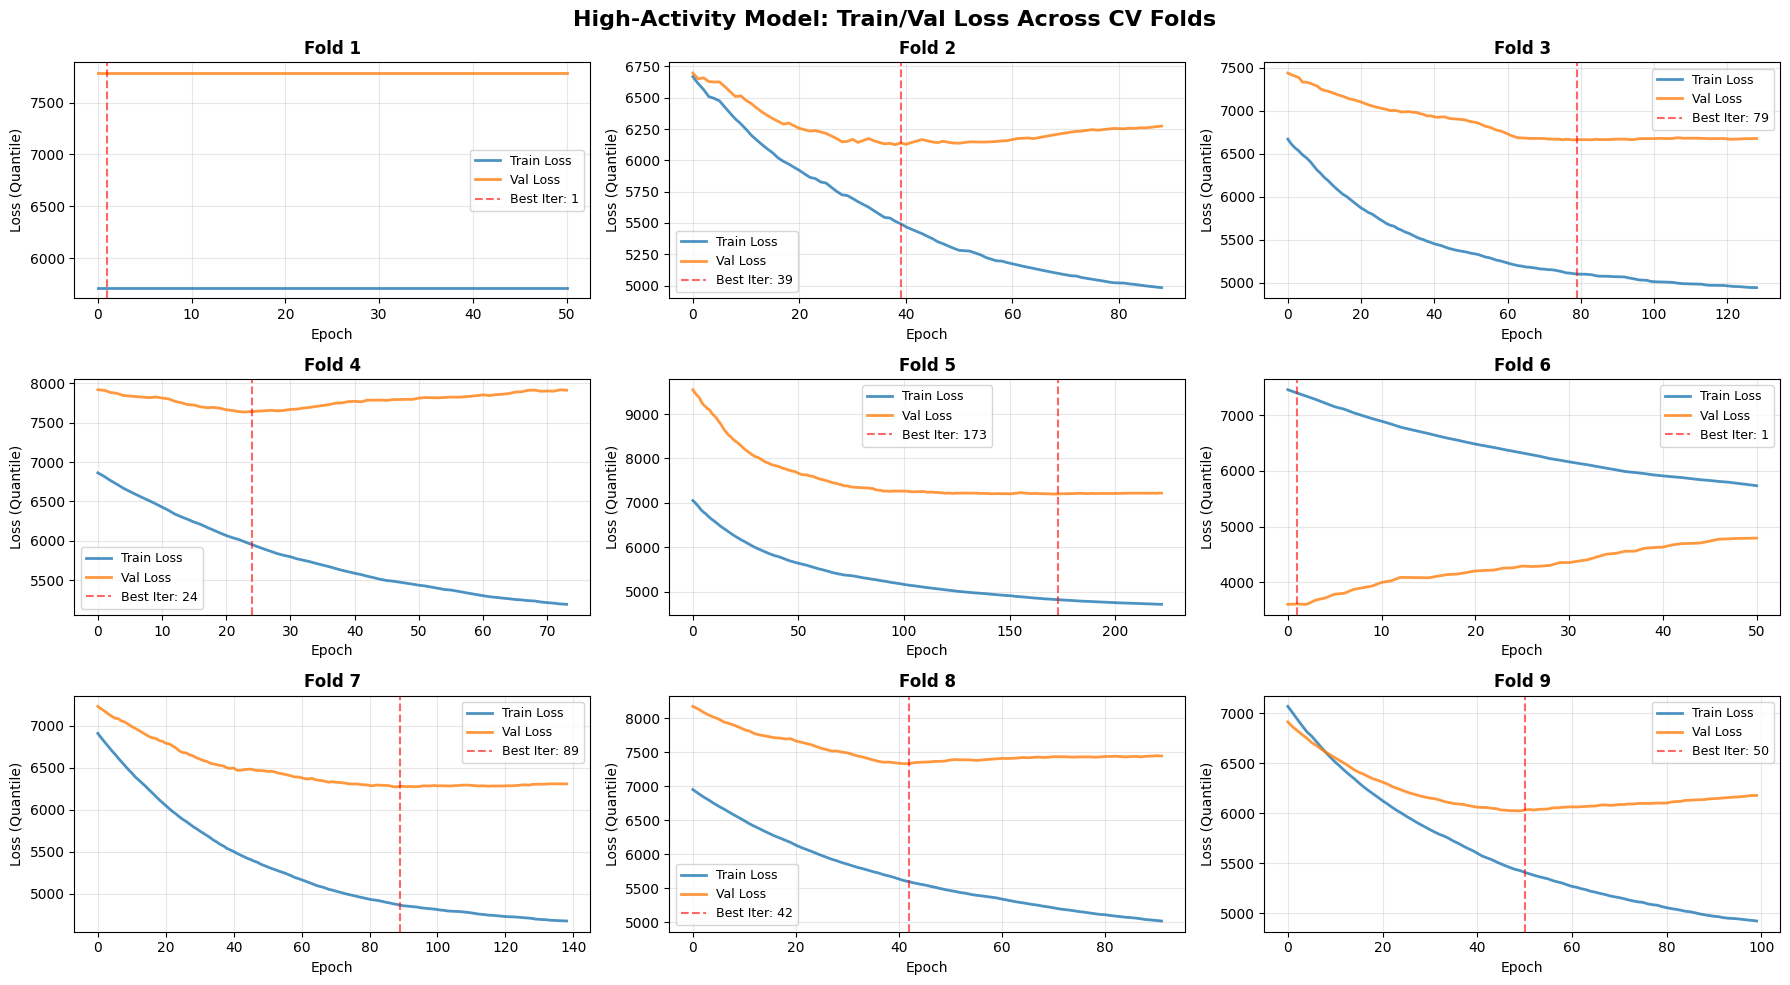

In [20]:


# ============================================================================
# PLOT ALL FOLDS - MID-ACTIVITY MODEL
# ============================================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
fig.suptitle('Mid-Activity Model: Train/Val Loss Across CV Folds', fontsize=16, fontweight='bold')
for i, hist in enumerate(histories_mid):
    row = i // 3
    col = i % 3
    
    ax = axes[row, col]
    ax.plot(hist['train_loss'], label='Train Loss', linewidth=2, alpha=0.8)
    ax.plot(hist['val_loss'], label='Val Loss', linewidth=2, alpha=0.8)
    ax.axvline(hist['best_iteration'], color='red', linestyle='--', alpha=0.6, label=f"Best Iter: {hist['best_iteration']}")
    ax.set_title(f"Fold {hist['fold']}", fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (Quantile)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# PLOT ALL FOLDS - HIGH-ACTIVITY MODEL
# ============================================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
fig.suptitle('High-Activity Model: Train/Val Loss Across CV Folds', fontsize=16, fontweight='bold')

for i, hist in enumerate(histories_high):
    row = i // 3
    col = i % 3
    
    ax = axes[row, col]
    ax.plot(hist['train_loss'], label='Train Loss', linewidth=2, alpha=0.8)
    ax.plot(hist['val_loss'], label='Val Loss', linewidth=2, alpha=0.8)
    ax.axvline(hist['best_iteration'], color='red', linestyle='--', alpha=0.6, label=f"Best Iter: {hist['best_iteration']}")
    ax.set_title(f"Fold {hist['fold']}", fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (Quantile)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)



plt.tight_layout()
plt.show()


## Predicting

In [14]:



print("\n[INFERENCE] Generating DAILY predictions with full feature parity...")
print("-" * 80)

feature_cols_mid = model_mid.feature_name_
feature_cols_high = model_high.feature_name_

# Get all unique prediction dates and sort chronologically
prediction_dates = sorted(prediction_mapping['forecast_end_date'].unique())
prediction_dates = [pd.to_datetime(d) - timedelta(1) for d in prediction_dates]

# Initialize: start with historical data up to forecast start
# We'll build a "synthetic history" dataframe that mimics training_df structure
synthetic_history = []

# Add actual historical receivals to synthetic_history
for rm_id in active_rm_ids:
    hist = receivals[receivals['rm_id'] == rm_id].copy()
    for _, rec in hist.iterrows():
        synthetic_history.append({
            'rm_id': rm_id,
            'train_date': rec['date_arrival'],
            'target': rec['net_weight'],
            'is_predicted': False  # Mark as actual history
        })

# Convert to DataFrame for easier manipulation
history_df = pd.DataFrame(synthetic_history)
history_df = history_df.sort_values(['rm_id', 'train_date']).reset_index(drop=True)

predictions = []
count_low = count_mid = count_high = weird_count = 0
n_total = len(prediction_mapping)


print(f"Total predictions to generate: {n_total:,}")
print(f"Prediction dates: {len(prediction_dates)} unique dates\n")

# Cumulative store per rm_id (for the final output)
rm_id_cum = defaultdict(float)

# Process each date chronologically
for date_idx, pred_date in enumerate(prediction_dates):
    print(f"\nProcessing date {date_idx + 1}/{len(prediction_dates)}: {pred_date.date()}...")
    
    # Get all rm_ids that need predictions on this date
    day_predictions = prediction_mapping[
        pd.to_datetime(prediction_mapping['forecast_end_date']) - timedelta(1) == pred_date
    ]
    
    for idx, row in day_predictions.iterrows():
        rm_id = row['rm_id']
        
        # ====================================================================
        # GET HISTORICAL DATA (including previously predicted values)
        # ====================================================================
        hist_data = history_df[
            (history_df['rm_id'] == rm_id) & 
            (history_df['train_date'] < pred_date)
        ].copy()
        
        # ====================================================================
        # DETERMINE ACTIVITY LEVEL
        # ====================================================================
        if rm_id in high_activity_rms:
            activity_level = 'high'
        elif rm_id in mid_activity_rms:
            activity_level = 'mid'
        else:
            activity_level = 'low'
        
        # ====================================================================
        # TEMPORAL FEATURES (same as training)
        # ====================================================================
        day_of_week = pred_date.dayofweek
        day_of_month = pred_date.day
        month = pred_date.month
        is_weekend = 1 if day_of_week >= 5 else 0
        is_holiday = 1 if pred_date in hdays else 0
        is_other_pattern = 1 if any(pattern in pred_date.strftime('%Y-%m-%d') 
                                     for pattern in other_patterns) else 0
        
        # ====================================================================
        # HISTORICAL RECEIVAL FEATURES (same as training)
        # ====================================================================
        cutoff_365 = pred_date - timedelta(365)
        cutoff_180 = pred_date - timedelta(180)
        cutoff_90 = pred_date - timedelta(90)
        cutoff_30 = pred_date - timedelta(30)
        cutoff_7 = pred_date - timedelta(7)
        
        rec_365 = hist_data[hist_data['train_date'] >= cutoff_365]
        rec_180 = hist_data[hist_data['train_date'] >= cutoff_180]
        rec_90 = hist_data[hist_data['train_date'] >= cutoff_90]
        rec_30 = hist_data[hist_data['train_date'] >= cutoff_30]
        rec_7 = hist_data[hist_data['train_date'] >= cutoff_7]
        
        rec_count_7d = len(rec_7)
        rec_weight_7d = rec_7['target'].sum()
        rec_count_30d = len(rec_30)
        rec_weight_30d = rec_30['target'].sum()
        rec_count_90d = len(rec_90)
        rec_weight_90d = rec_90['target'].sum()
        rec_count_180d = len(rec_180)
        rec_weight_180d = rec_180['target'].sum()
        rec_count_365d = len(rec_365)
        rec_weight_365d = rec_365['target'].sum()
        
        days_since_last_recv = (pred_date - hist_data['train_date'].max()).days \
                               if len(hist_data) > 0 else np.nan
        
        # ====================================================================
        # PURCHASE ORDER FEATURES (same as training)
        # ====================================================================
        pos_on_day = purchase_orders[
            (purchase_orders['rm_id'] == rm_id) & 
            (purchase_orders['delivery_date'] == pred_date)
        ]
        pos = pos_on_day['quantity'].sum() if len(pos_on_day) > 0 else 0.0
        
        av_pos_7d = purchase_orders[
            (purchase_orders['rm_id'] == rm_id) & 
            (purchase_orders['delivery_date'] >= pred_date - timedelta(3)) & 
            (purchase_orders['delivery_date'] < pred_date + timedelta(3))
        ]
        av_pos_7d = av_pos_7d['quantity'].mean() if len(av_pos_7d) > 0 else 0.0
        
        av_pos_15d = purchase_orders[
            (purchase_orders['rm_id'] == rm_id) & 
            (purchase_orders['delivery_date'] >= pred_date - timedelta(7)) & 
            (purchase_orders['delivery_date'] < pred_date + timedelta(7))
        ]
        av_pos_15d = av_pos_15d['quantity'].mean() if len(av_pos_15d) > 0 else 0.0
        
        activation_date = pd.to_datetime(activation.get(rm_id))
        activated = 1 if activation_date <= pred_date else 0
        
        # ====================================================================
        # LAG FEATURES (using hist_data which includes predictions)
        # ====================================================================
        hist_sorted = hist_data.sort_values('train_date', ascending=False)
        
        lag_1 = hist_sorted.iloc[0]['target'] if len(hist_sorted) >= 1 else 0.0
        lag_2 = hist_sorted.iloc[1]['target'] if len(hist_sorted) >= 2 else 0.0
        lag_3 = hist_sorted.iloc[2]['target'] if len(hist_sorted) >= 3 else 0.0
        lag_7 = hist_sorted.iloc[6]['target'] if len(hist_sorted) >= 7 else 0.0
        lag_14 = hist_sorted.iloc[13]['target'] if len(hist_sorted) >= 14 else 0.0
        lag_28 = hist_sorted.iloc[27]['target'] if len(hist_sorted) >= 28 else 0.0
        
        # ====================================================================
        # ROLLING STATISTICS (using lag_1 shifted history)
        # ====================================================================
        # Get last N days for rolling calculations (excluding today)
        def get_rolling_stat(window_days, stat_func):
            cutoff = pred_date - timedelta(window_days)
            window_data = hist_data[hist_data['train_date'] >= cutoff]['target']
            if len(window_data) == 0:
                return 0.0 if stat_func in ['sum', 'mean'] else np.nan
            if stat_func == 'sum':
                return window_data.sum()
            elif stat_func == 'mean':
                return window_data.mean()
            elif stat_func == 'std':
                return window_data.std() if len(window_data) >= 2 else np.nan
            return 0.0
        
        sum_7d = get_rolling_stat(7, 'sum')
        mean_7d = get_rolling_stat(7, 'mean')
        sum_14d = get_rolling_stat(14, 'sum')
        mean_14d = get_rolling_stat(14, 'mean')
        sum_30d = get_rolling_stat(30, 'sum')
        mean_30d = get_rolling_stat(30, 'mean')
        sum_90d = get_rolling_stat(90, 'sum')
        mean_90d = get_rolling_stat(90, 'mean')
        
        std_7d = get_rolling_stat(7, 'std')
        std_30d = get_rolling_stat(30, 'std')
        
        # Activity ratio (non-zero frequency)
        active_30 = hist_data[hist_data['train_date'] >= pred_date - timedelta(30)]
        active_ratio_30 = (active_30['target'] > 0).mean() if len(active_30) > 0 else 0.0
        
        # ====================================================================
        # MODEL SELECTION & PREDICTION
        # ====================================================================
        if activity_level == 'low':
            daily_pred = 0.0
            count_low += 1
        else:
            # Select model
            if activity_level == 'high':
                model = model_high
                feature_cols_model = feature_cols_high
                count_high += 1
            else:
                model = model_mid
                feature_cols_model = feature_cols_mid
                count_mid += 1
            
            # Build feature row matching training exactly
            feature_row = {
                'rm_id': rm_id,
                'is_weekend': is_weekend,
                'is_holiday': is_holiday,
                'is_other_pattern': is_other_pattern,
                'day_of_week': day_of_week,
                'day_of_month': day_of_month,
                'month': month,
                'rec_count_7d': rec_count_7d,
                'rec_weight_7d': rec_weight_7d,
                'rec_count_30d': rec_count_30d,
                'rec_weight_30d': rec_weight_30d,
                'rec_count_90d': rec_count_90d,
                'rec_weight_90d': rec_weight_90d,
                'rec_count_180d': rec_count_180d,
                'rec_weight_180d': rec_weight_180d,
                'rec_count_365d': rec_count_365d,
                'rec_weight_365d': rec_weight_365d,
                'days_since_last_recv': days_since_last_recv,
                'pos': pos,
                'av_pos_7d': av_pos_7d,
                'av_pos_15d': av_pos_15d,
                'activated': activated,
                'lag_1': lag_1,
                'lag_2': lag_2,
                'lag_3': lag_3,
                'lag_7': lag_7,
                'lag_14': lag_14,
                'lag_28': lag_28,
                'sum_7d': sum_7d,
                'mean_7d': mean_7d,
                'sum_14d': sum_14d,
                'mean_14d': mean_14d,
                'sum_30d': sum_30d,
                'mean_30d': mean_30d,
                'sum_90d': sum_90d,
                'mean_90d': mean_90d,
                'std_7d': std_7d,
                'std_30d': std_30d,
                'active_ratio_30': active_ratio_30
            }
            
            # Only keep features that the model was trained on
            X = pd.DataFrame(feature_row, index=[0])[feature_cols_model]
            
            
            daily_pred = model.predict(X)[0]
            if daily_pred < 0:
                daily_pred = 0.0
                weird_count += 1
        
        # ====================================================================
        # ACCUMULATE & STORE
        # ====================================================================
        rm_id_cum[rm_id] += daily_pred
        
        predictions.append({
            'ID': row['ID'],
            'rm_id': rm_id,
            'predict_date': pred_date,
            'daily_weight': daily_pred,
            'predicted_weight': rm_id_cum[rm_id]
        })
        
        # ====================================================================
        # ADD PREDICTION TO HISTORY for future predictions
        # ====================================================================
        history_df = pd.concat([
            history_df,
            pd.DataFrame([{
                'rm_id': rm_id,
                'train_date': pred_date,
                'target': daily_pred,
                'is_predicted': True
            }])
        ], ignore_index=True)

# Final output
predictions_df = pd.DataFrame(predictions).sort_values('ID')

print("\n[PREDICTION COMPLETE - DAILY WITH FULL FEATURES]")
print("-" * 80)
print(f"Total predictions       : {len(predictions_df):,}")
print(f"Low-activity routed to 0: {count_low:,}")
print(f"Mid-activity predictions: {count_mid:,}")
print(f"High-activity predictions: {count_high:,}")
print("-" * 80)
print("✅ All daily predictions generated with feature parity!")


[INFERENCE] Generating DAILY predictions with full feature parity...
--------------------------------------------------------------------------------
Total predictions to generate: 30,450
Prediction dates: 150 unique dates


Processing date 1/150: 2025-01-01...

Processing date 2/150: 2025-01-02...

Processing date 3/150: 2025-01-03...

Processing date 4/150: 2025-01-04...

Processing date 5/150: 2025-01-05...

Processing date 6/150: 2025-01-06...

Processing date 7/150: 2025-01-07...

Processing date 8/150: 2025-01-08...

Processing date 9/150: 2025-01-09...

Processing date 10/150: 2025-01-10...

Processing date 11/150: 2025-01-11...

Processing date 12/150: 2025-01-12...

Processing date 13/150: 2025-01-13...

Processing date 14/150: 2025-01-14...

Processing date 15/150: 2025-01-15...

Processing date 16/150: 2025-01-16...

Processing date 17/150: 2025-01-17...

Processing date 18/150: 2025-01-18...

Processing date 19/150: 2025-01-19...

Processing date 20/150: 2025-01-20...

Pro

## Make Predictions

In [15]:
# Print names of all rm_ids that had non-zero predictions
non_zero_rms = predictions_df[predictions_df['daily_weight'] > 0]['rm_id'].unique()
print(f"\nRM_IDs with non-zero predictions ({len(non_zero_rms)} total):")
print(non_zero_rms)


print(all(rm in non_zero_rms for rm in high_activity_rms))
print(all(rm in non_zero_rms for rm in mid_activity_rms))


RM_IDs with non-zero predictions (22 total):
[2131 2145 2140 2143 2142 2130 2135 2134 2144 3123 3122 3126 3124 3125
 3265 3282 3362 3421 3781 3865 3901 4222]
True
True


In [16]:
predictions_df[predictions_df['rm_id'] == 3865.0].head(20)

,ID,rm_id,predict_date,daily_weight,predicted_weight
177,26551,3865,2025-01-01,0.000000,0.000000
380,26552,3865,2025-01-02,1729.490411,1729.490411
583,26553,3865,2025-01-03,1729.490411,3458.980822
786,26554,3865,2025-01-04,0.000000,3458.980822
989,26555,3865,2025-01-05,0.000000,3458.980822
1192,26556,3865,2025-01-06,1729.490411,5188.471234
1395,26557,3865,2025-01-07,1729.490411,6917.961645
1598,26558,3865,2025-01-08,1751.462802,8669.424447
1801,26559,3865,2025-01-09,1729.490411,10398.914858
2004,26560,3865,2025-01-10,1729.490411,12128.405269


In [17]:
# Save predictions
predictions_df[['ID', 'predicted_weight']].to_csv('more_preds.csv', index=False)

## Feature Importance


[ANALYSIS] Plotting feature importances for trained models...
--------------------------------------------------------------------------------


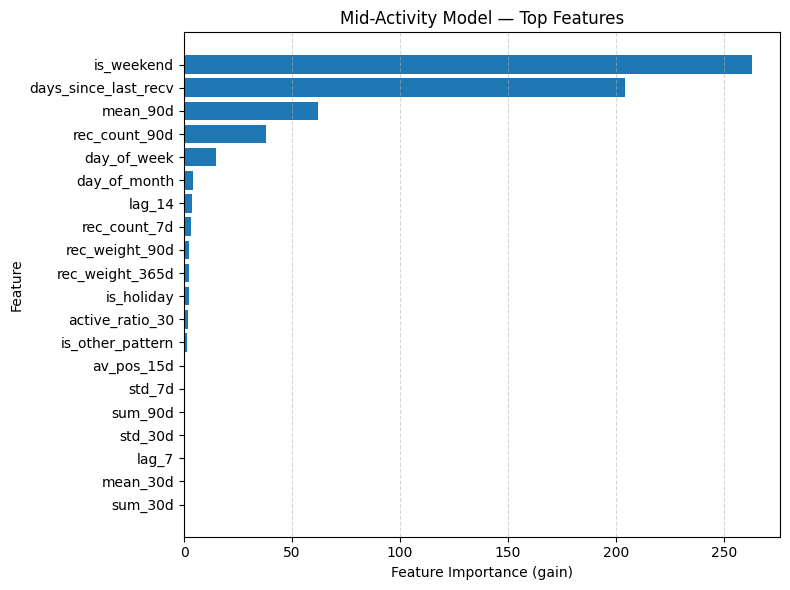

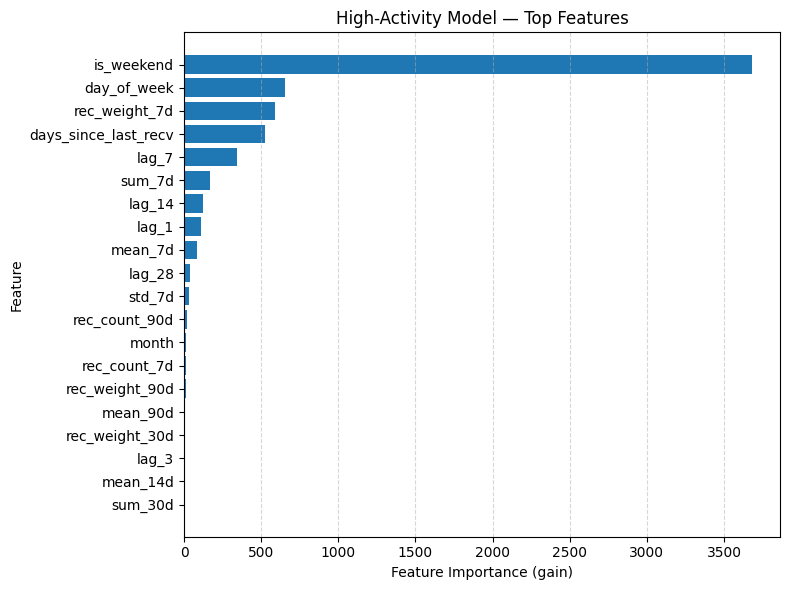


Top features comparison (Low vs Mid vs High Activity):


,feature,mid_activity_gain,high_activity_gain
0,rm_id,0.000000,0.000000
1,is_weekend,262.936005,3678.561974
2,is_holiday,2.140400,0.000000
3,is_other_pattern,1.269310,0.000000
4,day_of_week,14.773450,655.744235
5,day_of_month,4.153869,6.439146
6,month,0.000000,15.548594
7,rec_count_7d,3.151750,10.848586
8,rec_weight_7d,0.000000,590.874230
9,rec_count_30d,0.000000,4.792703


In [18]:


def plot_feature_importance(model, title, top_n=20):
    """
    Plots the top N most important features from a trained LightGBM model.
    """
    importance = model.booster_.feature_importance(importance_type='gain')
    feature_names = model.booster_.feature_name()
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(8, 6))
    plt.barh(importance_df['feature'][:top_n][::-1],
             importance_df['importance'][:top_n][::-1])
    plt.title(title)
    plt.xlabel('Feature Importance (gain)')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return importance_df


# ============================================================================
# PLOT FOR BOTH MODELS
# ============================================================================

print("\n[ANALYSIS] Plotting feature importances for trained models...")
print("-" * 80)

# importance_low = plot_feature_importance(model_low, "Low-Activity Model — Top Features")

importance_mid = plot_feature_importance(model_mid, "Mid-Activity Model — Top Features")

importance_high = plot_feature_importance(model_high, "High-Activity Model — Top Features")

# Optional: combine into one table for comparison
importance_compare = pd.DataFrame({
    'feature': importance_mid['feature'],
    #'low_activity_gain': importance_low['importance'],
    'mid_activity_gain': importance_mid['importance'],
    'high_activity_gain': importance_high['importance']
})

# Show top features from both models side-by-side
print("\nTop features comparison (Low vs Mid vs High Activity):")
display(importance_compare.head(20))
